# Adding CPI as a Feature

The original model only uses past prices to predict future prices — it has no awareness of the broader economy.

Uganda's **Food CPI** (Consumer Price Index for Food and Non-Alcoholic Beverages), published monthly by UBOS, captures inflation in the food basket. When food inflation is rising, maize prices tend to rise with it.

In this notebook we:
1. Extract the monthly Food CPI from the UBOS Excel file
2. Preview it to make sure it looks right before touching anything else

In [1]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "openpyxl"], check=True)


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


CompletedProcess(args=['/Users/pascal/projects/east-africa-food-prices/.venv/bin/python', '-m', 'pip', 'install', 'openpyxl'], returncode=0)

In [3]:
import openpyxl
import pandas as pd

wb = openpyxl.load_workbook("data/raw/03_2026CPI_March_2026_Excel_Tables.xlsx", read_only=True)
ws = wb["Division "]
rows = list(ws.iter_rows(values_only=True))

# Row 0 = header (dates), Row 1 = Food and Non-Alcoholic Beverages
# Dates and values start at column index 3 (columns 0-2 are: number, name, weight)
header_row = rows[0]
food_row = rows[1]

records = []
for date, value in zip(header_row[3:], food_row[3:]):
    if date is not None and value is not None:
        records.append({"year": date.year, "month": date.month, "food_cpi": round(float(value), 4)})

cpi_df = pd.DataFrame(records)
print(f"{len(cpi_df)} months of data: {cpi_df['year'].min()} to {cpi_df['year'].max()}")
cpi_df.head(10)

105 months of data: 2017 to 2026


,year,month,food_cpi
0,2017,7,104.3234
1,2017,8,104.9649
2,2017,9,106.0877
3,2017,10,106.3810
4,2017,11,105.5663
5,2017,12,104.4369
6,2018,1,103.8786
7,2018,2,104.3366
8,2018,3,104.8064
9,2018,4,105.5477


## Save CPI to CSV

We save the extracted CPI to a CSV file in the `data/` folder. This way we only parse the Excel once — future notebooks and the API can just read the CSV.

In [ ]:
cpi_df.to_csv("data/food_cpi_monthly.csv", index=False)
print("Saved → data/food_cpi_monthly.csv")


Saved → data/food_cpi_monthly.csv


## Merge CPI with Maize Price Data

Our maize training data runs from 2006 to 2022. The CPI only starts July 2017, so after merging we'll only keep rows where both exist — that gives us roughly July 2017 to 2022 as our new training window.

We merge on `year` and `month`.


In [ ]:
maize_df = pd.read_csv("wfp_food_prices_uga.csv")
maize_df["date"] = pd.to_datetime(maize_df["date"])
maize_df = (
    maize_df[
        maize_df["commodity"].str.contains("Maize", case=False, na=False) &
        (maize_df["market"] == "Owino")
    ]
    .copy()
    .sort_values("date")
    .reset_index(drop=True)
)
maize_df["year"] = maize_df["date"].dt.year
maize_df["month"] = maize_df["date"].dt.month

merged = maize_df.merge(cpi_df, on=["year", "month"], how="inner")
print(f"Maize rows: {len(maize_df)}")
print(f"After merge with CPI: {len(merged)} rows")
print(f"Date range: {merged['date'].min().date()} to {merged['date'].max().date()}")
merged[["date", "price", "food_cpi"]].head(10)


Maize rows: 439
After merge with CPI: 173 rows
Date range: 2017-07-15 to 2025-04-15


,date,price,food_cpi
0,2017-07-15,1783.00,104.3234
1,2017-07-15,1125.00,104.3234
2,2017-07-15,859.69,104.3234
3,2017-07-15,2617.00,104.3234
4,2017-08-15,1500.00,104.9649
5,2017-08-15,1150.00,104.9649
6,2017-08-15,2700.00,104.9649
7,2017-09-15,1022.24,106.0877
8,2017-09-15,1000.00,106.0877
9,2017-10-15,900.00,106.3810


## Build Feature Matrix

We use the same 7 features as the original model, plus `food_cpi` as the 8th.

Each row uses the 6 months of prices *before* the target month to compute lag and rolling features, then attaches the CPI for that target month.


In [ ]:
import sys
sys.path.insert(0, "../food_prices_api")
from features import compute_features

prices_series = merged["price"].tolist()
feature_rows = []
targets = []

for i in range(6, len(merged)):
    past_prices = prices_series[i - 6 : i]
    row = merged.iloc[i]
    feats = compute_features(past_prices, int(row["month"]), int(row["year"]))
    feats["food_cpi"] = row["food_cpi"]
    feature_rows.append(feats)
    targets.append(prices_series[i])

FEATURE_COLS = [
    "price_lag_1", "price_lag_2", "price_lag_3",
    "rolling_mean_3", "rolling_mean_6",
    "month", "year", "food_cpi",
]

X = pd.DataFrame(feature_rows)[FEATURE_COLS]
y = pd.Series(targets)
print(f"Feature matrix shape: {X.shape}")
X.head()


Feature matrix shape: (167, 8)


,price_lag_1,price_lag_2,price_lag_3,rolling_mean_3,rolling_mean_6,month,year,food_cpi
0,1150.00,1500.00,2617.00,1755.6667,1505.7817,8,2017,104.9649
1,2700.00,1150.00,1500.00,1783.3333,1658.6150,9,2017,106.0877
2,1022.24,2700.00,1150.00,1624.0800,1641.4883,9,2017,106.0877
3,1000.00,1022.24,2700.00,1574.0800,1664.8733,10,2017,106.3810
4,900.00,1000.00,1022.24,974.0800,1378.7067,10,2017,106.3810


## Train/Test Split and Retrain

We keep the same rule as the original model: train on data up to end of 2019, test on 2020 onwards.


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

merged_trimmed = merged.iloc[6:].reset_index(drop=True)

train_mask = merged_trimmed["year"] <= 2019
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMAE : {mae:,.0f} UGX/kg")
print(f"R²  : {r2:.4f}")


Train: 58 rows | Test: 109 rows

MAE : 658 UGX/kg
R²  : 0.0481


## Baseline Comparison

Train a model without CPI on the same data and same split, so we're comparing apples to apples.


In [ ]:
BASELINE_COLS = [
    "price_lag_1", "price_lag_2", "price_lag_3",
    "rolling_mean_3", "rolling_mean_6",
    "month", "year",
]

X_train_base = X_train[BASELINE_COLS]
X_test_base = X_test[BASELINE_COLS]

baseline = RandomForestRegressor(n_estimators=200, random_state=42)
baseline.fit(X_train_base, y_train)
y_pred_base = baseline.predict(X_test_base)

print("=== Baseline (no CPI) ===")
print(f"MAE : {mean_absolute_error(y_test, y_pred_base):,.0f} UGX/kg")
print(f"R²  : {r2_score(y_test, y_pred_base):.4f}")

print("\n=== With CPI ===")
print(f"MAE : {mae:,.0f} UGX/kg")
print(f"R²  : {r2:.4f}")


=== Baseline (no CPI) ===
MAE : 678 UGX/kg
R²  : -0.0134

=== With CPI ===
MAE : 658 UGX/kg
R²  : 0.0481


## Feature Importance

Which features is the model actually relying on? If CPI ranks high, it's genuinely useful signal.


In [ ]:
importance = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print(importance.round(4))


rolling_mean_3    0.1607
price_lag_3       0.1581
price_lag_1       0.1528
rolling_mean_6    0.1440
food_cpi          0.1331
price_lag_2       0.1298
month             0.0716
year              0.0497
dtype: float64


## Save the Model

We save this as `maize_price_model_v2.pkl`. We'll upload it to HuggingFace Hub separately and update the API to use it.

In [ ]:
import joblib

joblib.dump(model, "maize_price_model_v2.pkl")
print("Saved → maize_price_model_v2.pkl")


Saved → maize_price_model_v2.pkl


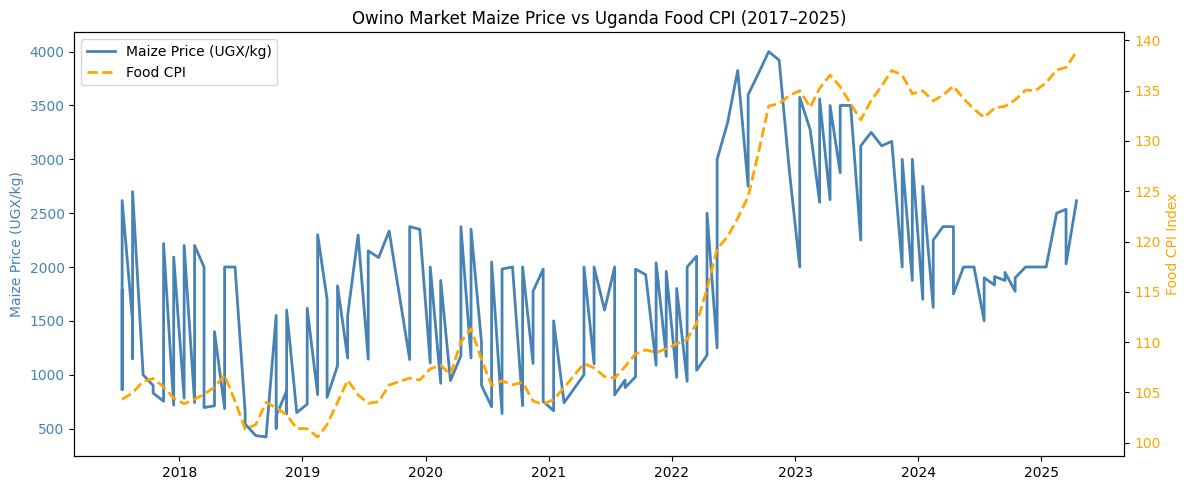

Saved → maize_vs_cpi.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax1 = plt.subplots(figsize=(12, 5))

# Maize price
ax1.plot(merged["date"], merged["price"], color="steelblue", linewidth=2, label="Maize Price (UGX/kg)")
ax1.set_ylabel("Maize Price (UGX/kg)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

# CPI on second axis
ax2 = ax1.twinx()
ax2.plot(merged["date"], merged["food_cpi"], color="orange", linewidth=2, linestyle="--", label="Food CPI")
ax2.set_ylabel("Food CPI Index", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Owino Market Maize Price vs Uganda Food CPI (2017–2025)")
plt.tight_layout()
plt.savefig("maize_vs_cpi.png", dpi=150)
plt.show()
print("Saved → maize_vs_cpi.png")


## Extracting Maize-Specific CPI

The broad Food CPI includes cooking oil, sugar, meat, and many other items.
A more direct signal is the maize-specific index from the Decomposed sheet:
- "Whole grain maize" (01.1.1.1.1)
- "Maize Flour" (01.1.1.2.1)

We extract both and create a combined maize CPI by averaging them.


In [4]:
wb2 = openpyxl.load_workbook("data/raw/03_2026CPI_March_2026_Excel_Tables.xlsx", read_only=True)
ws2 = wb2["Decomposed"]
rows2 = list(ws2.iter_rows(values_only=True))

# Row 0 = header (labels), find dates row
header = rows2[0]
print("First 5 rows:")
for row in rows2[:5]:
    print(row[0], "|", row[1])


First 5 rows:
Row Labels | Weights
Core Index | 839.6199670508148
01.1.1.1.1 Whole grain maize | 0.993901034944442
01.1.1.1.2Simsim Grains | 1.6531592051510375
01.1.1.1.3Sorghum Grains | 0.5089194205423362


In [5]:
print("First 3 rows, first 8 columns:")
for row in rows2[:3]:
    print(row[:8])


First 3 rows, first 8 columns:
('Row Labels', 'Weights', datetime.datetime(2017, 7, 11, 0, 0), datetime.datetime(2017, 8, 11, 0, 0), datetime.datetime(2017, 9, 11, 0, 0), datetime.datetime(2017, 10, 11, 0, 0), datetime.datetime(2017, 11, 11, 0, 0), datetime.datetime(2017, 12, 11, 0, 0))
('Core Index', 839.6199670508148, 102.46860929703786, 102.76490162009426, 103.05235463053597, 103.27829056749, 103.60824174635873, 104.01645712655734)
('01.1.1.1.1 Whole grain maize', 0.993901034944442, 135.85012702228673, 108.48616943578672, 91.12414830703779, 85.15421118594512, 77.40081852972273, 72.4919710552295)


In [6]:
# Find the maize-specific rows
dates_row = rows2[0]
maize_records = []

for row in rows2:
    label = str(row[0]) if row[0] else ""
    if "Whole grain maize" in label or "Maize Flour" in label:
        print(f"Found: {label}")
        for date, value in zip(dates_row[2:], row[2:]):
            if date is not None and value is not None:
                maize_records.append({
                    "year": date.year,
                    "month": date.month,
                    "series": label.strip(),
                    "value": round(float(value), 4)
                })

maize_cpi_raw = pd.DataFrame(maize_records)
print(f"\nRows extracted: {len(maize_cpi_raw)}")
maize_cpi_raw.head(6)


Found: 01.1.1.1.1 Whole grain maize
Found: 01.1.1.2.1 Maize Flour 

Rows extracted: 210


,year,month,series,value
0,2017,7,01.1.1.1.1 Whole grain maize,135.8501
1,2017,8,01.1.1.1.1 Whole grain maize,108.4862
2,2017,9,01.1.1.1.1 Whole grain maize,91.1241
3,2017,10,01.1.1.1.1 Whole grain maize,85.1542
4,2017,11,01.1.1.1.1 Whole grain maize,77.4008
5,2017,12,01.1.1.1.1 Whole grain maize,72.4920


In [7]:
maize_cpi = (
    maize_cpi_raw.groupby(["year", "month"], as_index=False)["value"]
    .mean()
    .rename(columns={"value": "maize_cpi"})
)
maize_cpi["maize_cpi"] = maize_cpi["maize_cpi"].round(4)

print(f"Rows: {len(maize_cpi)}")
maize_cpi.head(6)


Rows: 105


,year,month,maize_cpi
0,2017,7,127.4615
1,2017,8,112.9988
2,2017,9,104.3758
3,2017,10,101.1602
4,2017,11,93.6602
5,2017,12,89.1538


In [8]:
maize_cpi.to_csv("data/maize_cpi_monthly.csv", index=False)
print("Saved → data/maize_cpi_monthly.csv")


Saved → data/maize_cpi_monthly.csv


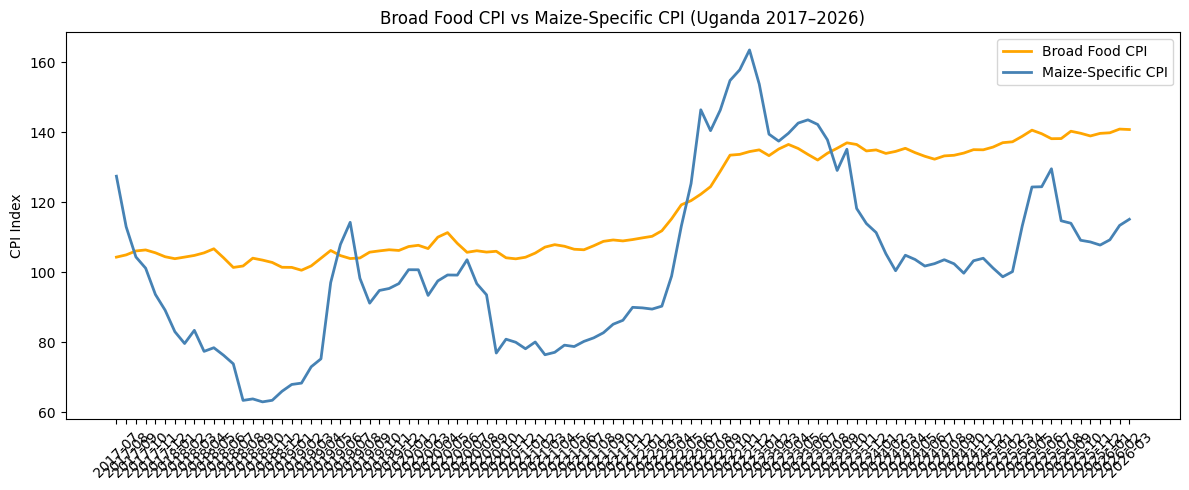

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(cpi_df["year"].astype(str) + "-" + cpi_df["month"].astype(str).str.zfill(2),
        cpi_df["food_cpi"], label="Broad Food CPI", color="orange", linewidth=2)
ax.plot(maize_cpi["year"].astype(str) + "-" + maize_cpi["month"].astype(str).str.zfill(2),
        maize_cpi["maize_cpi"], label="Maize-Specific CPI", color="steelblue", linewidth=2)

ax.set_title("Broad Food CPI vs Maize-Specific CPI (Uganda 2017–2026)")
ax.set_ylabel("CPI Index")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("broad_vs_maize_cpi.png", dpi=150)
plt.show()
